In [1]:
import tensorflow as tf
tf.random.set_seed(101)
import numpy as np
np.random.seed(101)
import keras
keras.backend.clear_session()
from random import choice
import os
import seaborn as sns
from adjustText import adjust_text
import argparse
import json
import pandas as pd
import sys
from datetime import datetime
import matplotlib.pyplot as plt
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, Layer
import plotly.express as px
#import dash
#import dash_core_components as dcc
#import dash_html_components as html
#from dash.dependencies import Input, Output
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')
from colorama import init, Fore, Style
import plotly.offline as offline
#import matplotlib.cm as cm
#import matplotlib
import matplotlib as mpl

## Análisis figuras Nominate

In [2]:

# Asignación de los argumentos a variables correspondientes
DATASET = 'Francia'

# Leer metadatos de usuarios desde un archivo CSV
userMetadata = pd.read_csv(f'../data/Dataset 4, popup_screen_france.csv')


# Cargar el archivo CSV de coordenadas las propuestasresults/coordsU/Francia_29_05_2024_17_19_38.csv
coordsP = pd.read_csv('results/coordsP/Francia_31_07_2024_12_03_38.csv')

# Cargar el archivo TSV de etiquetas de coordenadas
labels_coords = pd.read_csv('../data/labels/Dataset 5, set_proposals_france.csv').rename(columns={'issue_id': 'option_id'})

# Combinar (merge) los DataFrames coordsP y labels_coords en base a la columna 'option_id'
coordsP = coordsP.merge(labels_coords, on='option_id')

# Cargar el archivo CSV de coordenadas Usuarios
coordsU = pd.read_csv('results/coordsU/Francia_31_07_2024_12_03_38.csv')
coordsU = pd.merge(userMetadata, coordsU,on='user_id')
#coordsU['z2'] = np.abs(1-coordsU['z2'])
coordsU['z1_1'] = np.abs(1-coordsU['z1'])
coordsU['z1'] = coordsU['z2']
coordsU['z2'] = coordsU['z1_1']

coordsP['z1_1'] = np.abs(1-coordsP['z1'])
coordsP['z1'] = coordsP['z2']
coordsP['z2'] = coordsP['z1_1']


In [3]:
#Se filtran aquellos clientes que no seleccionaron partido politico
coordsU = coordsU[coordsU['politica']!=99]

In [4]:
ranking = pd.read_excel('results/Ranking_propuestas_trueskill_Francia.xlsx')
ranking =ranking.rename({'id':'option_id'},axis=1)
ranking_coords = coordsP.merge(ranking,on='option_id')

In [9]:
from matplotlib.lines import Line2D
def graficar_usuario_propuesta(coordsP,lista_iz,lista_der):
        # --- Standardize fonts ---
    mpl.rcParams['font.size']       = 12
    mpl.rcParams['axes.labelsize']  = 14
    mpl.rcParams['axes.titlesize']  = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    # Crea un diccionario que mapee los nombres a 'square' (cuadrado) o 'diamond' (rombo)
    symbols_dict = {name: 'square' for name in lista_der}
    symbols_dict.update({name: 'diamond' for name in lista_iz})

    # Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
    symbols_dict.update({name: 'circle' for name in coordsP['es'] if name not in lista_iz and name not in lista_der})
    # Asigna 'circle' a los nombres que no están en las listas 'izquierda' ni 'derecha'
    coordsP['symbol'] = coordsP['es'].map(symbols_dict)

    # Define el tamaño de los símbolos
    symbol_size = [2 if symbol in ('square', 'diamond') else 0.5 for symbol in coordsP['symbol']]

    # Define los colores de los puntos como una nueva columna "colors" en coordsP
    coordsP['colors'] = ['blue' if symbol == 'square' else 'red' if symbol == 'diamond' else 'grey' for symbol in coordsP['symbol']]


    #Se agrega información de ranking
    coordsP['ranking'] = 'No ranking'

    for index, row in coordsP.iterrows():
        short_name = row['es']

        if short_name in lista_iz:
            coordsP.at[index, 'ranking'] = lista_iz.index(short_name)
        elif short_name in lista_der:
            coordsP.at[index, 'ranking'] = lista_der.index(short_name)

    coordsP = coordsP.sort_values(by='colors')

    colores = ["red", "blue"]
    iz = coordsU[(coordsU['politica'] >= 1) & (coordsU['politica'] <= 2)]
    der = coordsU[(coordsU['politica'] >= 4) & (coordsU['politica'] <= 5)]
    iz ['Political parties'] = 'Far-left [1,2]'
    der ['Political parties'] = 'Far-right [4,5]'
    extremos = pd.concat([iz,der],axis=0)

    # Crear una figura y subgráficos con tamaño fijo
    fig, axs = plt.subplots(figsize=(8, 8), gridspec_kw={'bottom': 0.15, 'left': 0.15, 'right': 0.85, 'top': 0.9})


    # Graficar el gráfico de densidad con jointplot
    sns.kdeplot(data=extremos, x='z1', y='z2', hue='Political parties', palette=colores,
                fill=True, alpha=0.6, ax=axs)

    # Graficar el gráfico de dispersión
    # Graficar el gráfico de dispersión
    scatter = sns.scatterplot(data=coordsP, x="z1", y="z2", hue='colors', palette=['blue', 'grey', 'red'], 
                          size='symbol', sizes={'circle': 50, 'square': 150, 'diamond': 150}, ax=axs)


    # Añadir texto con el nombre corto y el ranking a cada punto azul y rojo
    for index, row in coordsP.iterrows():
        short_name = row['es']
        ranking = row['ranking']
        x, y = row['z1'], row['z2']

        # Añadir texto solo a puntos azules y rojos
        if row['colors'] in ['blue', 'red']:
            # Ajusta el desplazamiento en x (puedes cambiar el valor según tus preferencias)
            x_offset = 0.02
            axs.text(x + x_offset, y, f'{ranking+1}', fontsize=10, ha='left', va='center')



    # Personalizar leyenda con etiquetas


    labels = ['Left','Right','Others']
    colors = ['red', 'blue', 'gray']
    handles = [Line2D([0], [0], marker='o', color=color, label=label, markersize=8,linestyle='None') for color, label in zip(colors, labels)]
    axs.legend(handles=handles, labels=labels)

    # Mostrar la figura
    plt.xlim(-0.05,1.05)
    plt.tight_layout()
    axs.axvline(x=0.5, color='gray', linestyle='--')
    
    plt.xlabel('Political Dimension 1')
    plt.ylabel('Political Dimension 2')

    # Dibujar una línea horizontal punteada en y=0.5
    axs.axhline(y=0.5, color='gray', linestyle='--')
    plt.savefig("Output/heatmap_france.svg", format='svg')
    plt.show()

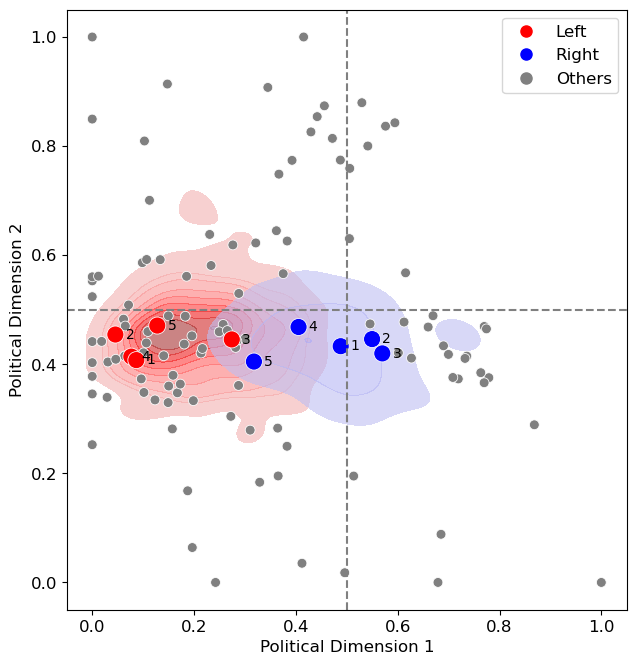

In [10]:
# Define la lista de nombres que deben tener el símbolo de cuadrado (square)
derecha_top5 = list(ranking_coords.sort_values("ranking_derecha_sort", ascending=True)['es_x'][0:5])

# Define la lista de nombres que deben tener el símbolo de rombo (diamond)
izquierda_top5 = list(ranking_coords.sort_values("ranking_izquierda_sort", ascending=True)['es_x'][0:5])

# Crear DataFrames para las listas
df_derecha = pd.DataFrame({'Propuesta': derecha_top5})
df_izquierda = pd.DataFrame({'Propuesta': izquierda_top5})


df_izquierda.index += 1  # Sumar uno a los índices
df_derecha.index += 1  # Sumar uno a los índices


graficar_usuario_propuesta(coordsP,izquierda_top5 ,derecha_top5 )